# Singapore Tourism Arrivals — Week 1: Data & Baseline Models

**Project:** Time Series Forecasting with Uncertainty Quantification  
**Data Source:** SingStat / Data.gov.sg  
**Goal:** Forecast monthly international visitor arrivals by country of origin

---

## Data Decisions Log
*(Update this as you work — this is what impresses interviewers)*

| Decision | Rationale |
|---|---|
| Time-based train/test split | Prevents data leakage — future data must never inform past predictions |
| Dropped rows where arrivals = 0 | True zeros vs missing data ambiguity; flagged in EDA |
| Log-transform target | Stabilises variance across orders of magnitude (China vs Brunei) |
| COVID window noted | 2020–2021 treated as structural break, not noise |

---

## 0. Setup & Dependencies

In [1]:
# Install dependencies (run once)
!pip install pandas numpy matplotlib seaborn statsmodels pmdarima requests

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Statsmodels for ARIMA/SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# pmdarima for auto order selection
import pmdarima as pm

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Aesthetics
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
SEED = 42

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Data Acquisition

### How to get the data

**Option A — SingStat Table Builder (recommended, most granular)**
1. Go to: https://tablebuilder.singstat.gov.sg/
2. Search: *"International Visitor Arrivals By Country Of Residence"*
3. Table ID: `M550001` (Monthly) — select all years and all countries
4. Download as CSV
5. Save to `data/raw_singstat.csv`

**Option B — Data.gov.sg API (programmatic)**
- Dataset: `international-visitor-arrivals-to-singapore-by-country`
- The cell below fetches it automatically via the Data.gov.sg API

> **Data Decision:** SingStat Table M550001 goes back to 1978 and covers ~60 countries of residence. We use this as the primary source. The Data.gov.sg version is a subset of the same data.

In [3]:
import requests
import pandas as pd
from pathlib import Path
 
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
 
def fetch_from_datagov():
    """
    Fetch from Data.gov.sg using the confirmed working dataset ID.
 
    Dataset: "International Visitor Arrivals By Place Of Residence, Monthly"
    ID: d_7e7b2ee60c6ffc962f80fef129cf306e  (adapted from SingStat M550001)
    Coverage: Jan 2008 → present (updated monthly)
 
    Note: If you need data before 2008, download manually from SingStat Table
    Builder (M550001) which goes back to 1978. For most modelling purposes
    2008–present is sufficient (17+ years, covers GFC + COVID).
    """
    DATASET_ID = "d_7e7b2ee60c6ffc962f80fef129cf306e"
    url = f"https://data.gov.sg/api/action/datastore_search"
 
    all_records = []
    offset = 0
    limit = 1000
 
    print(f"Fetching dataset {DATASET_ID}...")
    while True:
        try:
            resp = requests.get(
                url,
                params={'resource_id': DATASET_ID, 'limit': limit, 'offset': offset},
                timeout=15
            )
            resp.raise_for_status()
            result = resp.json()['result']
            records = result['records']
            if not records:
                break
            all_records.extend(records)
            total = result['total']
            print(f"  Fetched {min(offset + limit, total)}/{total} rows...", end='\r')
            offset += limit
            if offset >= total:
                break
        except Exception as e:
            print(f"\nStopped at offset {offset}: {e}")
            break
 
    if all_records:
        print(f"\nDone — {len(all_records)} rows fetched ✓")
        return pd.DataFrame(all_records)
    return None
 
 
raw_path = DATA_DIR / 'raw_singstat.csv'
 
if raw_path.exists():
    print(f"Loading from local cache: {raw_path}")
    raw_df = pd.read_csv(raw_path)
else:
    raw_df = fetch_from_datagov()
    if raw_df is not None:
        raw_df.to_csv(raw_path, index=False)
        print(f"Saved to {raw_path} ✓")
    else:
        print("""
        API fetch failed. Manual download:
          1. Go to https://data.gov.sg/datasets/d_7e7b2ee60c6ffc962f80fef129cf306e/view
          2. Click 'Download CSV'
          3. Save as data/raw_singstat.csv
        """)
        raw_df = None
 
if raw_df is not None:
    print(f"\nShape: {raw_df.shape}")
    print(f"Columns (first 5): {raw_df.columns[:5].tolist()}")
    raw_df.head(3)

Loading from local cache: data/raw_singstat.csv

Shape: (62, 219)
Columns (first 5): ['_id', 'DataSeries', '2026Jan', '2025Dec', '2025Nov']


---
## 2. Data Cleaning

Government data is rarely clean. Document every transformation.

In [4]:
def clean_datagov_wide(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans the Data.gov.sg wide-format CSV for M550001.
 
    Actual column format (confirmed from live API):
      - First column: 'DataSeries'  (country/region names)
      - Date columns: '2026Jan', '2025Dec', '2008Jan' ... (no space, no 'Numeric' suffix)
      - There is also a '_id' column from the API — we drop it
 
    Data decisions:
      - Drop '_id' and any all-null columns
      - Drop aggregate rows: 'Total International Visitor Arrivals...',
        region subtotals like 'Southeast Asia', 'Northeast Asia', etc.
      - Melt wide → long, parse '2026Jan' → datetime
      - Coverage: Jan 2008 → present (no pre-2008 data in this source)
    """
    df = df.copy()
 
    # Drop API metadata column
    if '_id' in df.columns:
        df = df.drop(columns=['_id'])
 
    # The country column is 'DataSeries'
    country_col = 'DataSeries'
    if country_col not in df.columns:
        # Fallback: first text column
        country_col = df.columns[0]
    print(f"Country column: '{country_col}'")
 
    # Identify date columns: match pattern like '2008Jan', '2026Jan'
    import re
    date_cols = [c for c in df.columns if re.match(r'^\d{4}[A-Za-z]{3}$', str(c))]
    print(f"Date columns found: {len(date_cols)} (from {date_cols[-1]} to {date_cols[0]})")
 
    # Melt wide → long
    df_long = df[[country_col] + date_cols].melt(
        id_vars=[country_col],
        var_name='date_str',
        value_name='arrivals'
    ).rename(columns={country_col: 'country'})
 
    # Parse dates: '2026Jan' → datetime
    df_long['date'] = pd.to_datetime(df_long['date_str'], format='%Y%b', errors='coerce')
 
    # Clean country names
    df_long['country'] = df_long['country'].astype(str).str.strip()
 
    # Convert arrivals to numeric
    df_long['arrivals'] = pd.to_numeric(
        df_long['arrivals'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    )
 
    # Drop rows with unparseable dates
    n_before = len(df_long)
    df_long = df_long.dropna(subset=['date'])
    if n_before > len(df_long):
        print(f"Dropped {n_before - len(df_long)} rows with unparseable dates")
 
    # Drop aggregate/regional rows — keep only country-level rows
    # These are rows that are subtotals, not individual countries
    aggregate_patterns = [
        'total international visitor',
        'southeast asia',
        'northeast asia',
        'south asia',
        'west asia',
        'americas',
        'europe',
        'oceania',
        'africa',
        'other markets',
        'others',
        '(null)',
        'nan',
    ]
    mask_agg = df_long['country'].str.lower().str.strip().apply(
        lambda x: any(pat in x for pat in aggregate_patterns)
    )
    dropped = df_long[mask_agg]['country'].unique()
    print(f"Removing {len(dropped)} aggregate rows: {list(dropped[:5])}{'...' if len(dropped) > 5 else ''}")
    df_long = df_long[~mask_agg]
 
    result = (
        df_long[['date', 'country', 'arrivals']]
        .sort_values(['country', 'date'])
        .reset_index(drop=True)
    )
    return result
 
 
# Run the corrected cleaning
if raw_df is not None:
    df = clean_datagov_wide(raw_df)
 
    print(f"\n{'='*50}")
    print(f"Cleaned shape:  {df.shape}")
    print(f"Date range:     {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"Countries:      {df['country'].nunique()}")
    print(f"Missing values: {df['arrivals'].isna().sum()} ({df['arrivals'].isna().mean():.1%})")
    print(f"{'='*50}")
 
    # Flag COVID window
    df['is_covid'] = ((df['date'] >= '2020-02-01') & (df['date'] <= '2021-12-31')).astype(int)
 
    df.to_csv(DATA_DIR / 'arrivals_clean.csv', index=False)
    print("Saved: data/arrivals_clean.csv ✓")
 
    print("\nSample rows:")
    print(df[df['country'] == df['country'].iloc[0]].head(6).to_string(index=False))

Country column: 'DataSeries'
Date columns found: 217 (from 2008Jan to 2026Jan)
Removing 19 aggregate rows: ['Total International Visitor Arrivals By Place Of Residence', 'Southeast Asia', 'Other Markets In Southeast Asia', 'Other Markets In Greater China', 'Other Markets In North Asia']...

Cleaned shape:  (9331, 3)
Date range:     2008-01-01 → 2026-01-01
Countries:      43
Missing values: 0 (0.0%)
Saved: data/arrivals_clean.csv ✓

Sample rows:
      date   country  arrivals  is_covid
2008-01-01 Australia     82778         0
2008-02-01 Australia     52457         0
2008-03-01 Australia     61681         0
2008-04-01 Australia     63079         0
2008-05-01 Australia     65901         0
2008-06-01 Australia     73802         0


In [5]:
# ── Missing data audit ──────────────────────────────────────────────────────

missing_by_country = (
    df.groupby('country')['arrivals']
    .agg(total='count', missing=lambda x: x.isna().sum())
    .assign(pct_missing=lambda x: x['missing'] / (x['total'] + x['missing']))
    .sort_values('pct_missing', ascending=False)
)

print("Countries with most missing data:")
print(missing_by_country[missing_by_country['missing'] > 0].head(15).to_string())

# Flag COVID period — this is a structural break, not noise
covid_mask = (df['date'] >= '2020-02-01') & (df['date'] <= '2021-12-31')
print(f"\n⚠ COVID window (Feb 2020 – Dec 2021): {covid_mask.sum()} rows flagged")
df['is_covid'] = covid_mask.astype(int)

Countries with most missing data:
Empty DataFrame
Columns: [total, missing, pct_missing]
Index: []

⚠ COVID window (Feb 2020 – Dec 2021): 989 rows flagged


In [6]:
# ── Select top countries by total arrivals (pre-COVID) ─────────────────────
# We focus on countries with long, complete histories for reliable modelling

pre_covid = df[df['date'] < '2020-01-01']
top_countries = (
    pre_covid.groupby('country')['arrivals']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 countries by pre-COVID arrivals:")
print(top_countries.apply(lambda x: f"{x:,.0f}").to_string())

TOP_COUNTRIES = top_countries.index.tolist()

# Save cleaned data
df.to_csv(DATA_DIR / 'arrivals_clean.csv', index=False)
print("\nSaved: data/arrivals_clean.csv ✓")

Top 15 countries by pre-COVID arrivals:
country
Greater China     35,730,626
Indonesia         32,072,596
China             26,033,587
North Asia        14,724,691
Malaysia          13,301,675
India             12,217,617
Australia         12,153,924
Japan              8,740,995
Philippines        7,803,241
USA                6,033,243
South Korea        5,974,770
United Kingdom     5,907,136
Thailand           5,704,652
Hong Kong SAR      5,642,799
Vietnam            4,933,555

Saved: data/arrivals_clean.csv ✓


---
## 3. Exploratory Data Analysis

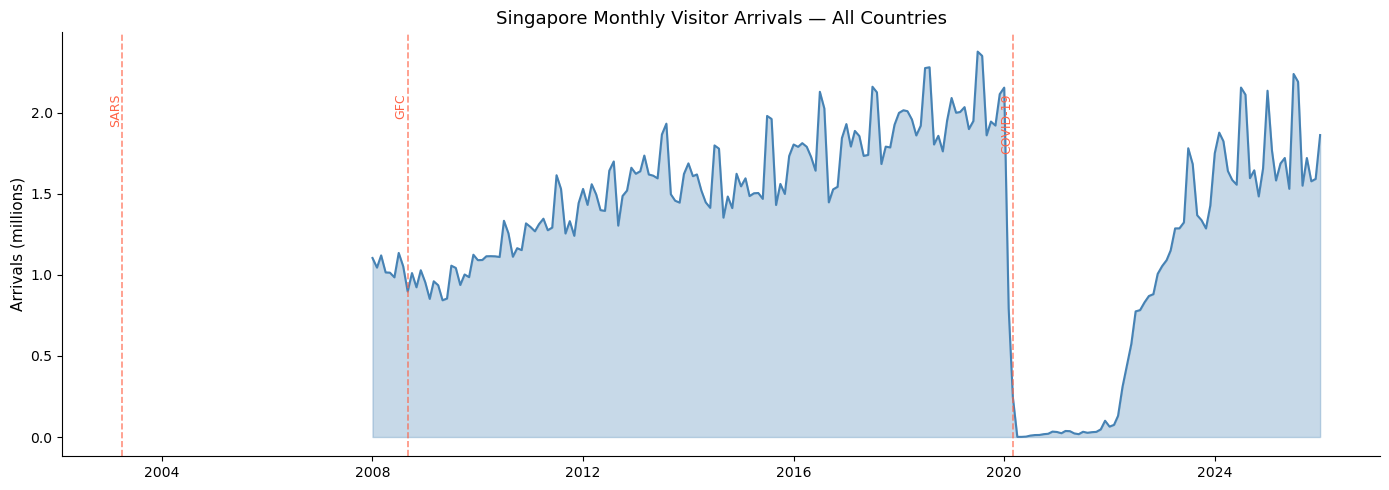

In [7]:
# ── Total arrivals over time ─────────────────────────────────────────────────
total_monthly = df.groupby('date')['arrivals'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(total_monthly['date'], total_monthly['arrivals'] / 1e6,
                alpha=0.3, color='steelblue')
ax.plot(total_monthly['date'], total_monthly['arrivals'] / 1e6,
        color='steelblue', lw=1.5)

# Annotate events
events = {
    '2003-04-01': 'SARS',
    '2008-09-01': 'GFC',
    '2020-03-01': 'COVID-19',
}
for date_str, label in events.items():
    ax.axvline(pd.to_datetime(date_str), color='tomato', lw=1.2, linestyle='--', alpha=0.7)
    ax.text(pd.to_datetime(date_str), ax.get_ylim()[1] * 0.85, label,
            rotation=90, va='top', ha='right', fontsize=9, color='tomato')

ax.set_title('Singapore Monthly Visitor Arrivals — All Countries')
ax.set_ylabel('Arrivals (millions)')
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_total_arrivals.png', dpi=150)
plt.show()

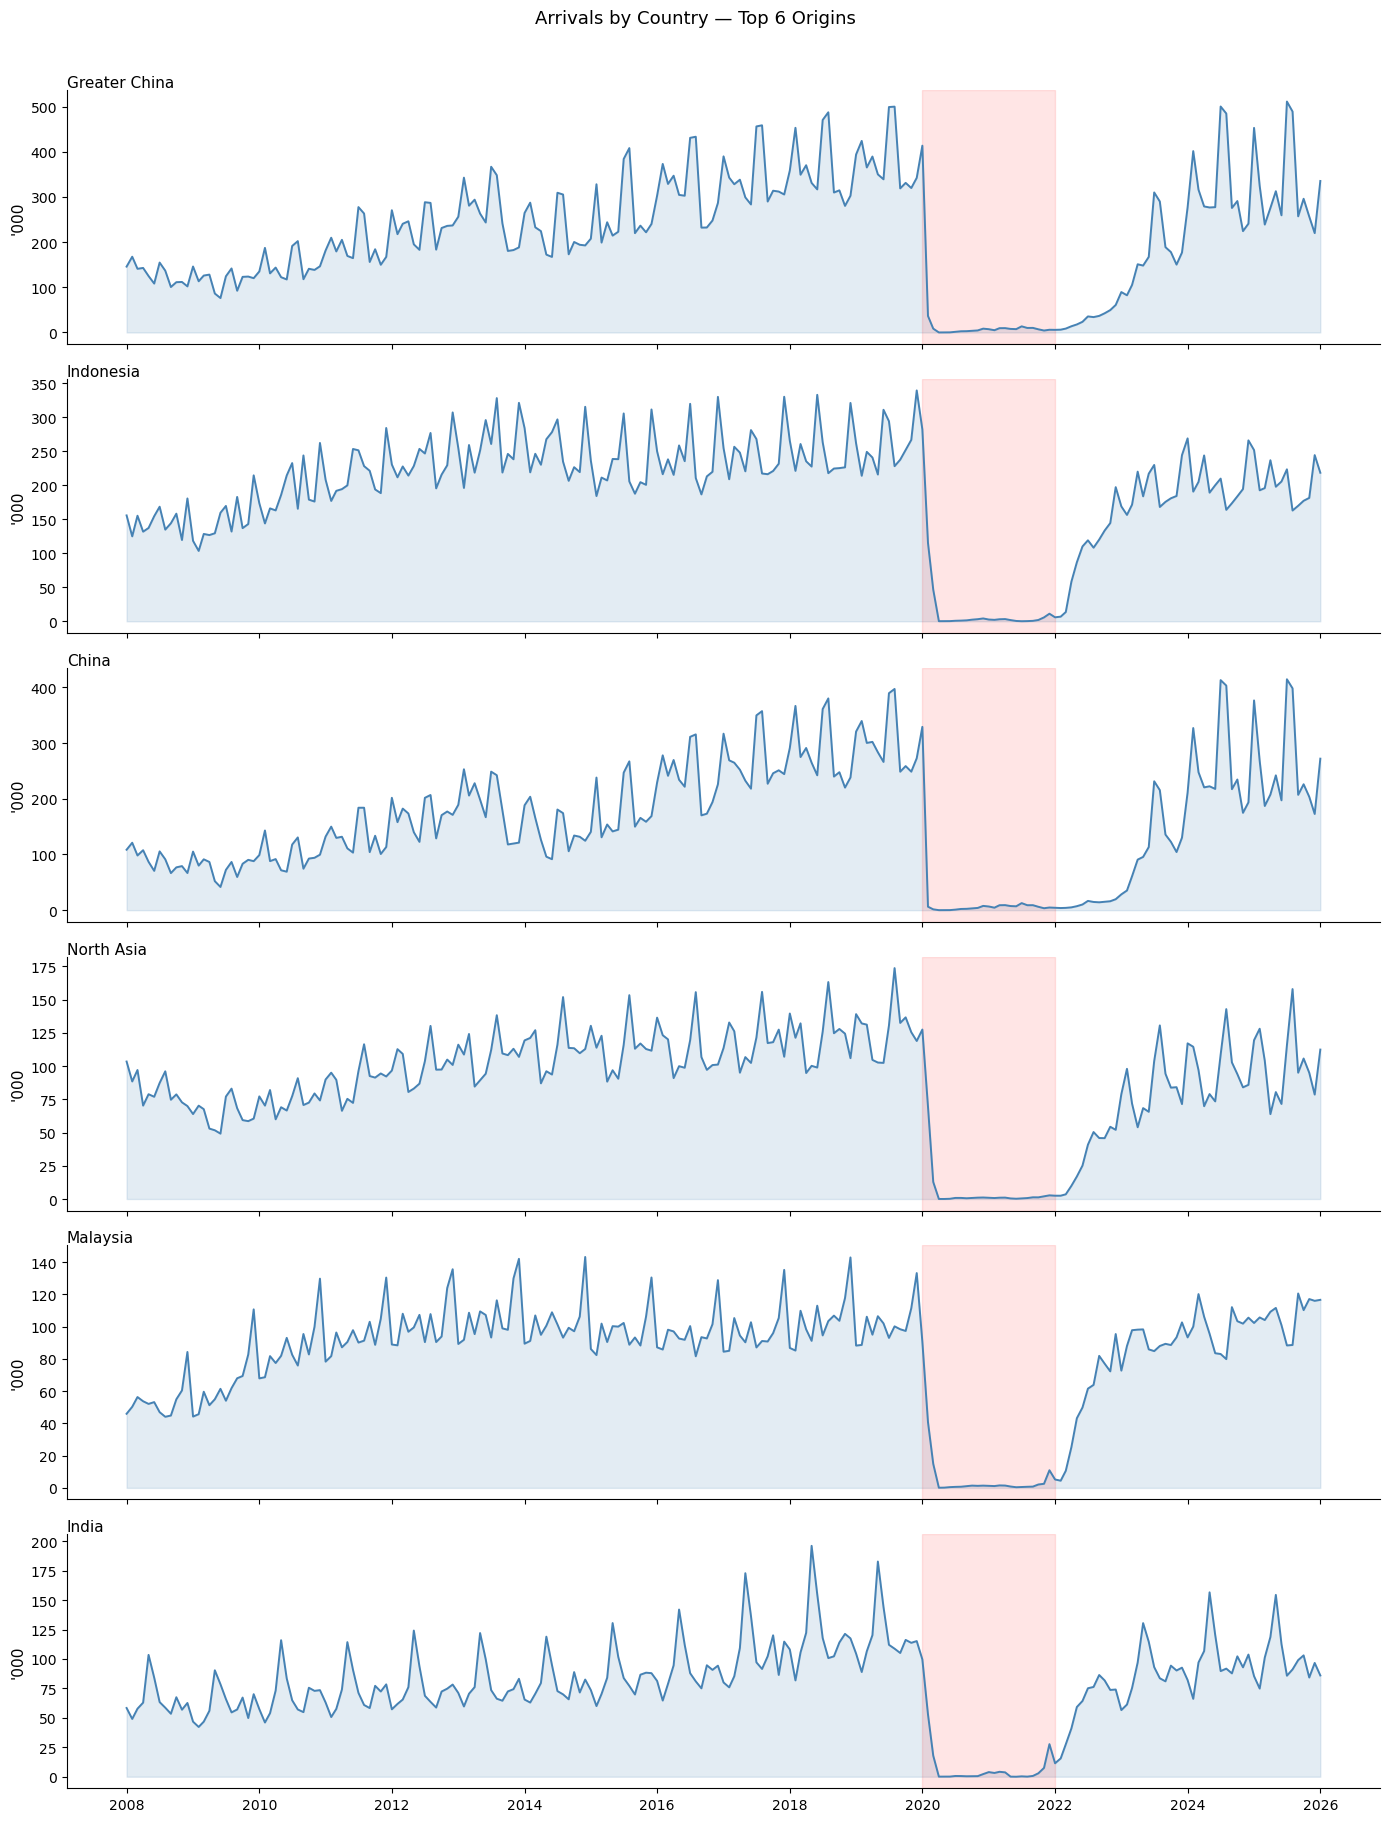

In [8]:
# ── Top country breakdown ────────────────────────────────────────────────────
n_show = 6
show_countries = TOP_COUNTRIES[:n_show]

fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=True)

for ax, country in zip(axes, show_countries):
    country_df = df[df['country'] == country].set_index('date')['arrivals'].asfreq('MS')
    ax.plot(country_df.index, country_df.values / 1e3, lw=1.4, color='steelblue')
    ax.fill_between(country_df.index, country_df.values / 1e3, alpha=0.15, color='steelblue')
    ax.set_ylabel("'000")
    ax.set_title(country, fontsize=11, loc='left', pad=2)
    ax.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2022-01-01'),
               alpha=0.1, color='red', label='COVID')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Arrivals by Country — Top 6 Origins', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_by_country.png', dpi=150)
plt.show()

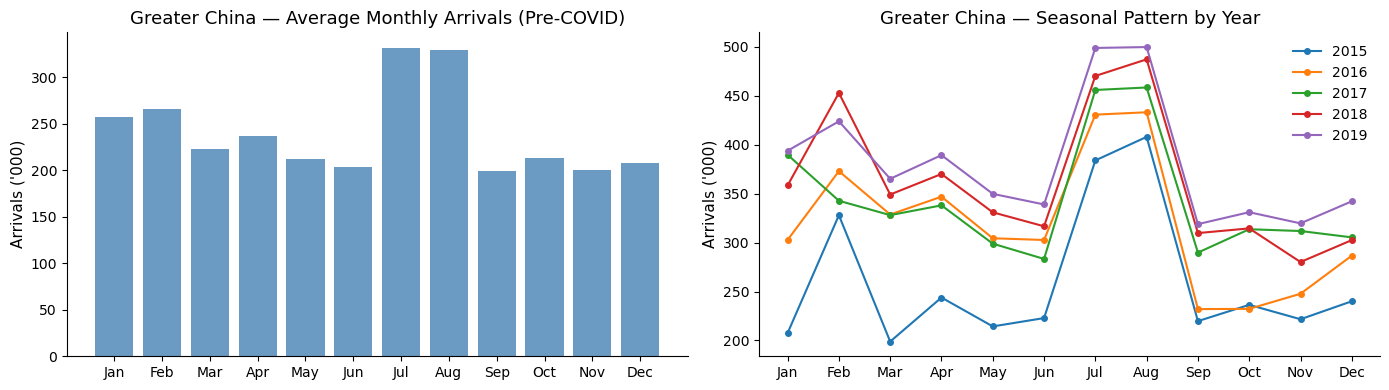

Peak month: Jul
Trough month: Sep


In [9]:
# ── Seasonality analysis ─────────────────────────────────────────────────────
# Use Indonesia as example (highest arrivals, long history)
FOCUS_COUNTRY = TOP_COUNTRIES[0]

country_df = (
    df[df['country'] == FOCUS_COUNTRY]
    .set_index('date')
    .sort_index()
)

# Monthly seasonality (pre-COVID only)
monthly_avg = (
    country_df[country_df['is_covid'] == 0]
    .assign(month=lambda x: x.index.month)
    .groupby('month')['arrivals']
    .mean()
)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly average
axes[0].bar(month_names, monthly_avg.values / 1e3, color='steelblue', alpha=0.8)
axes[0].set_title(f'{FOCUS_COUNTRY} — Average Monthly Arrivals (Pre-COVID)')
axes[0].set_ylabel("Arrivals ('000)")

# Year-on-year overlay
for year, grp in country_df[country_df.index.year.isin(range(2015, 2020))].assign(
    year=lambda x: x.index.year,
    month=lambda x: x.index.month
).groupby('year'):
    axes[1].plot(grp['month'], grp['arrivals'] / 1e3, marker='o', ms=4, label=str(year))

axes[1].set_title(f'{FOCUS_COUNTRY} — Seasonal Pattern by Year')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].legend(frameon=False)
axes[1].set_ylabel("Arrivals ('000)")

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_seasonality.png', dpi=150)
plt.show()

print(f"Peak month: {month_names[monthly_avg.idxmax()-1]}")
print(f"Trough month: {month_names[monthly_avg.idxmin()-1]}")

---
## 4. Stationarity Testing

> **Why this matters:** ARIMA assumes stationarity. We test formally rather than just eyeballing — this is a detail that separates rigorous work from cargo-cult time series analysis.

In [10]:
def stationarity_report(series: pd.Series, name: str) -> dict:
    """
    Run ADF and KPSS tests. Report both — they have opposite null hypotheses,
    so agreement gives stronger evidence.
    
    ADF H0: unit root present (non-stationary)
    KPSS H0: trend-stationary
    """
    series = series.dropna()
    
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='ct', nlags='auto')
    
    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p > 0.05  # fail to reject H0 = stationary
    
    result = {
        'series': name,
        'adf_p': round(adf_p, 4),
        'kpss_p': round(kpss_p, 4),
        'adf_conclusion': 'Stationary' if adf_stationary else 'Non-stationary',
        'kpss_conclusion': 'Stationary' if kpss_stationary else 'Non-stationary',
        'verdict': 'Stationary ✓' if (adf_stationary and kpss_stationary) else 'Needs differencing'
    }
    return result


# Test the focus country series (pre-COVID, log-transformed)
series_raw = country_df[country_df['is_covid'] == 0]['arrivals'].dropna()
series_log = np.log(series_raw)
series_diff = series_log.diff().dropna()
series_seasonal_diff = series_log.diff(12).dropna()

results = [
    stationarity_report(series_raw, 'Raw arrivals'),
    stationarity_report(series_log, 'Log arrivals'),
    stationarity_report(series_diff, 'Log + first diff'),
    stationarity_report(series_seasonal_diff, 'Log + seasonal diff (12)'),
]

stationarity_df = pd.DataFrame(results)
print(f"Stationarity tests — {FOCUS_COUNTRY}")
print(stationarity_df[['series','adf_p','kpss_p','adf_conclusion','kpss_conclusion','verdict']].to_string(index=False))

Stationarity tests — Greater China
                  series  adf_p  kpss_p adf_conclusion kpss_conclusion            verdict
            Raw arrivals 0.0275  0.0210     Stationary  Non-stationary Needs differencing
            Log arrivals 0.0019  0.0665     Stationary      Stationary       Stationary ✓
        Log + first diff 0.0000  0.1000     Stationary      Stationary       Stationary ✓
Log + seasonal diff (12) 0.0226  0.1000     Stationary      Stationary       Stationary ✓


/var/folders/t6/ct0hm3155vgdhyz6bhsvgpzw0000gn/T/ipykernel_27031/3784451091.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='ct', nlags='auto')
/var/folders/t6/ct0hm3155vgdhyz6bhsvgpzw0000gn/T/ipykernel_27031/3784451091.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='ct', nlags='auto')


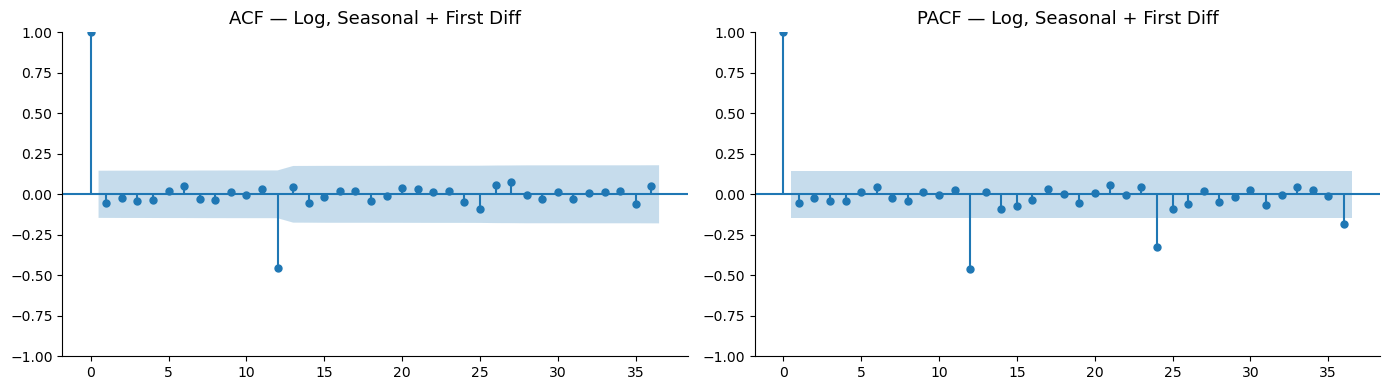


Reading the plots:
  ACF: spikes at lag 1, 12, 24 → seasonal MA terms
  PACF: spikes at lag 1-2 → AR terms
  → Starting point: SARIMA(1,1,1)(1,1,1)[12]
  → auto_arima below will confirm this



In [11]:
# ── ACF / PACF plots to guide order selection ────────────────────────────────
series_for_arima = series_log.diff(12).diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_for_arima, lags=36, ax=axes[0], title='ACF — Log, Seasonal + First Diff')
plot_pacf(series_for_arima, lags=36, ax=axes[1], title='PACF — Log, Seasonal + First Diff')
plt.tight_layout()
plt.savefig(DATA_DIR / 'acf_pacf.png', dpi=150)
plt.show()

print("""
Reading the plots:
  ACF: spikes at lag 1, 12, 24 → seasonal MA terms
  PACF: spikes at lag 1-2 → AR terms
  → Starting point: SARIMA(1,1,1)(1,1,1)[12]
  → auto_arima below will confirm this
""")

---
## 5. Train / Validation / Test Split

> **Key interview point:** We use **time-based splitting** — never random. Using future data to predict the past invalidates your entire evaluation. We also hold out COVID and post-COVID as separate test windows.

In [12]:
def make_splits(series: pd.Series) -> dict:
    """
    Time-based train / validation / test split.
    
    Split strategy:
      Train:      2010-01 → 2018-12  (most of pre-COVID history)
      Validation: 2019-01 → 2019-12  (hyperparameter tuning target)
      Test:       2022-01 → latest   (post-COVID recovery, held completely aside)
    
    COVID window (2020–2021) is excluded from standard evaluation
    but will be used in backtesting analysis in Week 4.
    """
    TRAIN_END = '2018-12-01'
    VAL_END   = '2019-12-01'
    TEST_START = '2022-01-01'
    
    train = series[series.index <= TRAIN_END]
    val   = series[(series.index > TRAIN_END) & (series.index <= VAL_END)]
    test  = series[series.index >= TEST_START]
    
    print(f"Train:      {train.index.min().date()} → {train.index.max().date()} ({len(train)} months)")
    print(f"Validation: {val.index.min().date()} → {val.index.max().date()} ({len(val)} months)")
    print(f"Test:       {test.index.min().date()} → {test.index.max().date()} ({len(test)} months)")
    print(f"COVID (excluded): 2020-01 → 2021-12")
    
    return {'train': train, 'val': val, 'test': test}


# Build series: log-transformed monthly arrivals
full_series = (
    df[df['country'] == FOCUS_COUNTRY]
    .set_index('date')
    .sort_index()['arrivals']
    .asfreq('MS')
    .pipe(np.log)
)

splits = make_splits(full_series)
train, val, test = splits['train'], splits['val'], splits['test']

Train:      2008-01-01 → 2018-12-01 (132 months)
Validation: 2019-01-01 → 2019-12-01 (12 months)
Test:       2022-01-01 → 2026-01-01 (49 months)
COVID (excluded): 2020-01 → 2021-12


---
## 6. Baseline Model 1 — ARIMA

We use `pmdarima.auto_arima` to select order automatically, then inspect it.

In [13]:
print(f"Fitting ARIMA on {FOCUS_COUNTRY} — train set ({len(train)} observations)")
print("Using auto_arima to select order via AIC (non-seasonal)...\n")

arima_model = pm.auto_arima(
    train,
    seasonal=False,          # no seasonality — SARIMA handles that below
    d=1,                     # fix first difference (confirmed by stationarity tests)
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True,
)

print(f"\nSelected order: ARIMA{arima_model.order}")
print(f"AIC: {arima_model.aic():.2f}")
print("\nModel summary:")
arima_model.summary()

Fitting ARIMA on Greater China — train set (132 observations)
Using auto_arima to select order via AIC (non-seasonal)...

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12.812, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=10.422, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-15.651, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=10.877, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-23.756, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-32.489, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-14.245, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-30.585, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-33.413, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-34.139, Time=0.05 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-34.303, Time=0.10 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-36.381, Time=0.15 s

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(2, 1, 3)   Log Likelihood                  28.884
Date:                Tue, 19 May 2026   AIC                            -43.769
Time:                        14:34:42   BIC                            -23.643
Sample:                    01-01-2008   HQIC                           -35.591
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0213      0.011      1.994      0.046       0.000       0.042
ar.L1         -0.9613      0.074    -12.917      0.000      -1.107      -0.815
ar.L2         -0.7760      0.074    -10.454      0.000      -0.922      -0.631
ma.L1          0.5001      0.072      6.960      0.000       0.359       0.641
ma.L2         -0.1754      0.102     -1.713      0.087      -0.376       0.025
ma.L3         -0.7223      0.072    -10.060      0.000      -0.863      -0.582
sigma2         0.0370      0.005      6.982      0.000       0.027       0.047
===================================================================================
Ljung-Box (L1) (Q):                   1.46   Jarque-Bera (JB):                 0.97
Prob(Q):                              0.23   Prob(JB):                         0.62
Heteroskedasticity (H):               1.04   Skew:                             0.10
Prob(H) (two-sided):                  0.89   Kurtosis:                         2.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

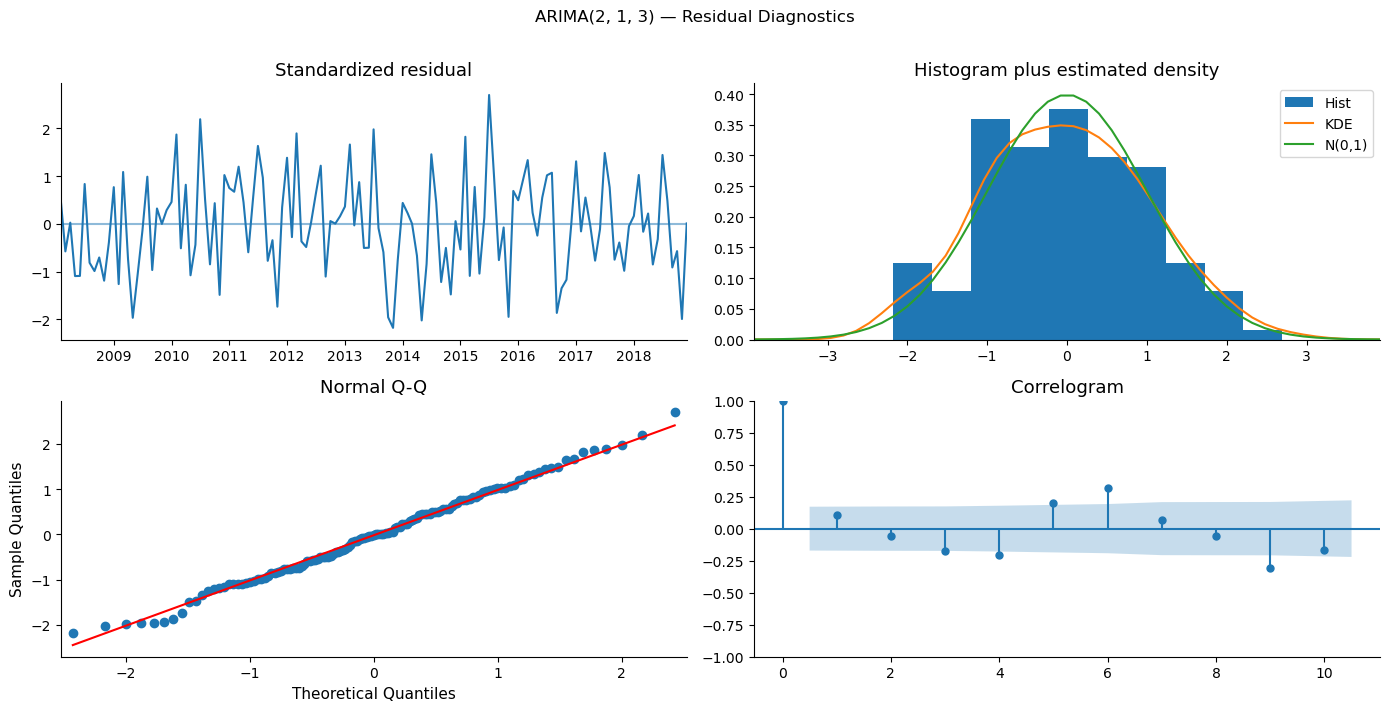

Ljung-Box test (lag 12):
  p-value: 1.0000
  ✓ No significant autocorrelation in residuals


In [14]:
# ── ARIMA residual diagnostics ───────────────────────────────────────────────
arima_model.plot_diagnostics(figsize=(14, 7))
plt.suptitle(f'ARIMA{arima_model.order} — Residual Diagnostics', y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'arima_diagnostics.png', dpi=150)
plt.show()

# Ljung-Box test for autocorrelation in residuals
residuals = arima_model.resid()
lb_result = acorr_ljungbox(residuals, lags=[12], return_df=True)
print("Ljung-Box test (lag 12):")
print(f"  p-value: {lb_result['lb_pvalue'].values[0]:.4f}")
if lb_result['lb_pvalue'].values[0] > 0.05:
    print("  ✓ No significant autocorrelation in residuals")
else:
    print("  ⚠ Residuals still autocorrelated — consider higher-order model or SARIMA")

In [15]:
# ── ARIMA validation forecast ────────────────────────────────────────────────
n_val = len(val)

arima_preds_log, arima_ci_log = arima_model.predict(
    n_periods=n_val,
    return_conf_int=True,
    alpha=0.05  # 95% interval
)

# Back-transform from log scale
arima_preds = np.exp(arima_preds_log)
arima_ci    = np.exp(arima_ci_log)
val_actual  = np.exp(val)

# Compute metrics
def compute_metrics(actual, predicted, ci_lower=None, ci_upper=None) -> dict:
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    metrics = {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}
    if ci_lower is not None and ci_upper is not None:
        coverage = np.mean((actual >= ci_lower) & (actual <= ci_upper)) * 100
        avg_width = np.mean(ci_upper - ci_lower)
        metrics['95% Coverage (%)'] = coverage
        metrics['Avg PI Width'] = avg_width
    return metrics

arima_metrics = compute_metrics(
    val_actual.values, arima_preds,
    arima_ci[:, 0], arima_ci[:, 1]
)

print("ARIMA Validation Metrics:")
for k, v in arima_metrics.items():
    print(f"  {k}: {v:,.2f}")

ARIMA Validation Metrics:
  MAE: 48,801.69
  RMSE: 59,859.85
  MAPE (%): 12.29
  95% Coverage (%): 100.00
  Avg PI Width: 355,185.84


---
## 7. Baseline Model 2 — Seasonal ARIMA (SARIMA)

> The clear seasonality in tourism data (school holidays, Chinese New Year, etc.) means ARIMA alone will underfit. SARIMA adds seasonal AR and MA terms.

In [16]:
print("Fitting SARIMA — this may take 1-2 minutes for grid search...\n")

sarima_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,                    # monthly seasonality
    d=1,
    D=1,                     # seasonal difference
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True,
)

print(f"\nSelected order: SARIMA{sarima_model.order}x{sarima_model.seasonal_order}")
print(f"AIC: {sarima_model.aic():.2f}")
sarima_model.summary()

Fitting SARIMA — this may take 1-2 minutes for grid search...

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=-153.458, Time=0.94 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-62.487, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-127.796, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.28 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=inf, Time=0.72 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=-126.056, Time=0.51 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=-154.429, Time=3.00 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=-147.628, Time=1.81 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=inf, Time=2.43 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=inf, Time=2.72 sec
 ARIMA(1,1,2)(2,1,1)[12]             : AIC=-155.918, Time=2.07 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=-154.962, Time=0.81 sec
 ARIMA(1,1,2)(2,1,0)[12]             : AIC=-149.561, Time=0.95 sec
 ARIMA(1,1,2)(2,1,2)[12]             : AIC=i

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(2, 1, 1, 12)   Log Likelihood                  84.806
Date:                            Tue, 19 May 2026   AIC                           -159.612
Time:                                    14:35:17   BIC                           -145.716
Sample:                                01-01-2008   HQIC                          -153.969
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4837      0.076     -6.386      0.000      -0.632      -0.335
ar.S.L12      -0.3211      0.167     -1.925      0.054      -0.648       0.006
ar.S.L24      -0.2346      0.130     -1.806      0.071      -0.489       0.020
ma.S.L12      -0.6363      0.167     -3.802      0.000      -0.964      -0.308
sigma2         0.0124      0.001      9.505      0.000       0.010       0.015
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                27.76
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.41   Skew:                            -0.65
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
# ── SARIMA validation forecast ───────────────────────────────────────────────
sarima_preds_log, sarima_ci_log = sarima_model.predict(
    n_periods=n_val,
    return_conf_int=True,
    alpha=0.05
)

sarima_preds = np.exp(sarima_preds_log)
sarima_ci    = np.exp(sarima_ci_log)

sarima_metrics = compute_metrics(
    val_actual.values, sarima_preds,
    sarima_ci[:, 0], sarima_ci[:, 1]
)

print("SARIMA Validation Metrics:")
for k, v in sarima_metrics.items():
    print(f"  {k}: {v:,.2f}")

SARIMA Validation Metrics:
  MAE: 13,268.09
  RMSE: 17,459.78
  MAPE (%): 3.18
  95% Coverage (%): 100.00
  Avg PI Width: 263,084.89


---
## 8. Model Comparison Plot

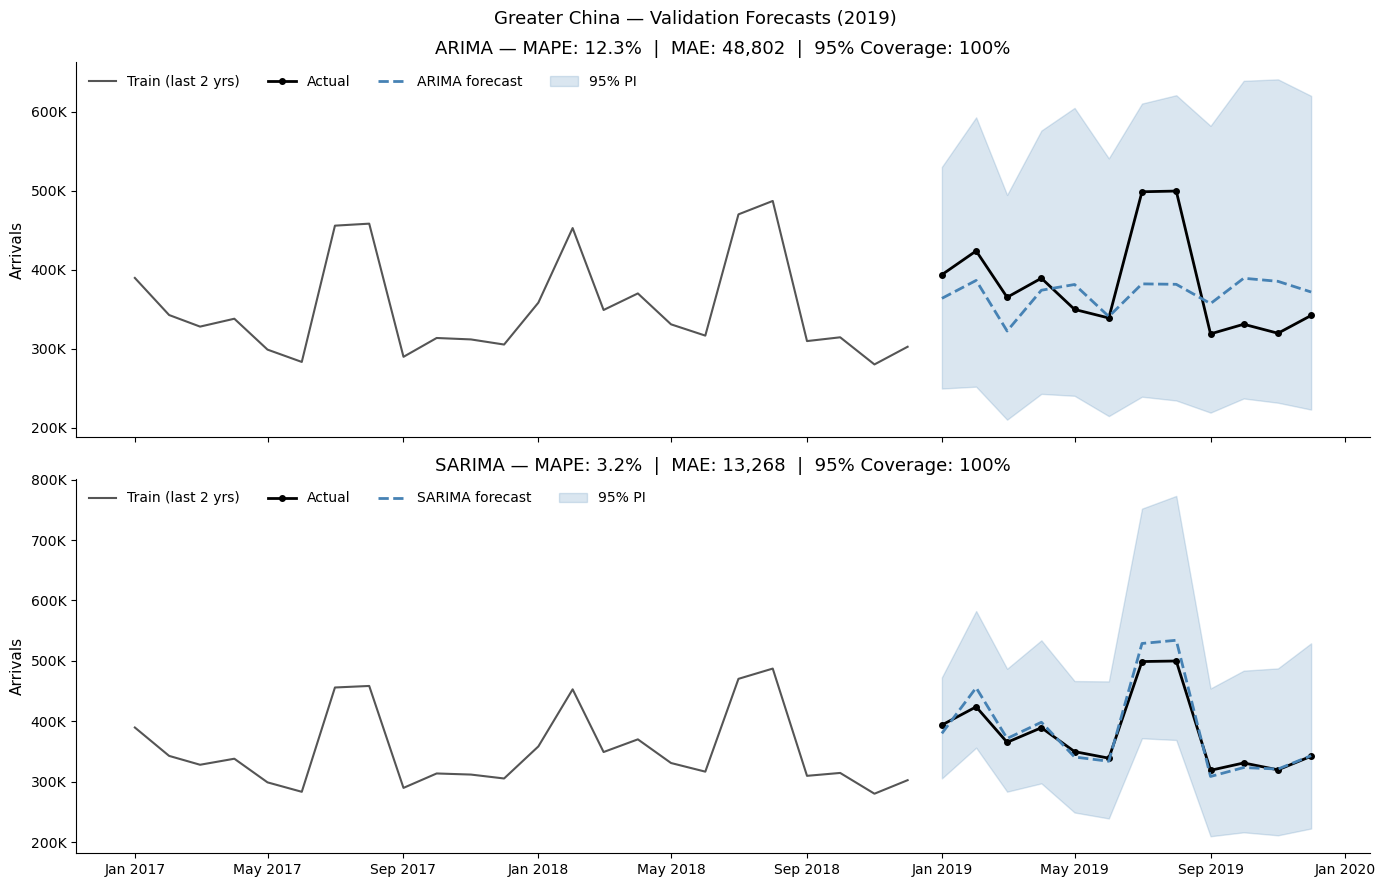

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

val_dates = val.index

for ax, (model_name, preds, ci) in zip(axes, [
    ('ARIMA', arima_preds, arima_ci),
    ('SARIMA', sarima_preds, sarima_ci),
]):
    # Training tail
    ax.plot(train.index[-24:], np.exp(train.values[-24:]),
            color='#555', lw=1.5, label='Train (last 2 yrs)')
    # Actuals
    ax.plot(val_dates, val_actual.values,
            color='black', lw=2, marker='o', ms=4, label='Actual')
    # Forecast
    ax.plot(val_dates, preds,
            color='steelblue', lw=2, linestyle='--', label=f'{model_name} forecast')
    # Confidence interval
    ax.fill_between(val_dates, ci[:, 0], ci[:, 1],
                    alpha=0.2, color='steelblue', label='95% PI')
    
    metrics = arima_metrics if model_name == 'ARIMA' else sarima_metrics
    ax.set_title(
        f'{model_name} — MAPE: {metrics["MAPE (%)"]:.1f}%  |  '
        f'MAE: {metrics["MAE"]:,.0f}  |  '
        f'95% Coverage: {metrics["95% Coverage (%)"]:.0f}%'
    )
    ax.set_ylabel("Arrivals")
    ax.legend(frameon=False, ncol=4)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.suptitle(f'{FOCUS_COUNTRY} — Validation Forecasts (2019)', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'model_comparison.png', dpi=150)
plt.show()

---
## 9. Week 1 Summary Table

This table seeds your Week 4 model comparison deliverable.

In [19]:
summary = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA'],
    'Order': [
        str(arima_model.order),
        f"{sarima_model.order}x{sarima_model.seasonal_order}"
    ],
    'AIC': [round(arima_model.aic(), 1), round(sarima_model.aic(), 1)],
    'MAE': [round(arima_metrics['MAE']), round(sarima_metrics['MAE'])],
    'RMSE': [round(arima_metrics['RMSE']), round(sarima_metrics['RMSE'])],
    'MAPE (%)': [round(arima_metrics['MAPE (%)'], 1), round(sarima_metrics['MAPE (%)'], 1)],
    '95% Coverage (%)': [
        round(arima_metrics['95% Coverage (%)']),
        round(sarima_metrics['95% Coverage (%)'])
    ],
    'Eval Window': ['2019 (12 months)', '2019 (12 months)'],
})

print(f"\n{'='*70}")
print(f"WEEK 1 RESULTS — {FOCUS_COUNTRY}")
print(f"{'='*70}")
print(summary.to_string(index=False))
print(f"{'='*70}")
print("Next: Week 2 — add Prophet and NeuralProphet to this table")

summary.to_csv(DATA_DIR / 'model_comparison_table.csv', index=False)
print("\nSaved: data/model_comparison_table.csv ✓")


WEEK 1 RESULTS — Greater China
 Model                   Order    AIC   MAE  RMSE  MAPE (%)  95% Coverage (%)      Eval Window
 ARIMA               (2, 1, 3)  -43.8 48802 59860      12.3               100 2019 (12 months)
SARIMA (0, 1, 1)x(2, 1, 1, 12) -159.6 13268 17460       3.2               100 2019 (12 months)
Next: Week 2 — add Prophet and NeuralProphet to this table

Saved: data/model_comparison_table.csv ✓


---
## 10. Recommended Project Structure

```
singapore-tourism-forecast/
├── data/
│   ├── raw_singstat.csv          # raw download, never modified
│   ├── arrivals_clean.csv        # output of this notebook
│   └── model_comparison_table.csv
├── notebooks/
│   ├── 01_data_and_baseline.ipynb    ← this notebook
│   ├── 02_prophet_neuralprophet.ipynb
│   ├── 03_uncertainty_quantification.ipynb
│   ├── 04_backtesting_framework.ipynb
│   └── 05_figures_for_readme.ipynb
├── src/
│   ├── data_loader.py
│   ├── models.py
│   ├── evaluation.py
│   └── backtesting.py
├── app/
│   └── streamlit_app.py
├── requirements.txt
└── README.md
```

## Week 2 Checklist
- [ ] Install `prophet` and `neuralprophet`
- [ ] Fit Prophet on same train set, same validation window
- [ ] Add Prophet and NeuralProphet rows to `model_comparison_table.csv`
- [ ] Note: Prophet needs `ds` and `y` column names — write a thin wrapper